In [1]:
import os
import matplotlib.pyplot as plt
import torch
from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from trainer import standard_trainer

from autoencoder import Autoenc

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": True, 
    "autoencoder": None, 
}

model_nr = 0
checkpoint = torch.load(f'checkpoints/base/model_weights{model_nr}.pth')

In [4]:
features = []

for data_key in data_keys:
    features_single_mouse = checkpoint[f'readout.{data_key}._features']
    features_single_mouse = features_single_mouse.squeeze().permute(1, 0).detach()
    features.append(features_single_mouse)

features = torch.cat(features)

In [21]:
hidden_dims = 1024
hidden_layers = 1
hidden_dims = [hidden_dims] * hidden_layers
autoencoder = Autoenc(64, 16, hidden_dims, batch_norm=True, nonlinearity='GELU')
autoencoder.to(device)

Autoenc(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=1024, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=1024, out_features=64, bias=True)
  )
)

In [22]:
criterion = torch.nn.MSELoss(reduction='sum')
optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.3, patience=100)

epochs = int(1e15)
min_lr = 1e-5

for epoch in range(epochs):
    recon = autoencoder(features)
    loss = criterion(features, recon)

    optim.zero_grad()
    loss.backward()
    optim.step()
    scheduler.step(loss.item())
    if epoch % 100 == 0:
        lr = optim.param_groups[0]['lr']
        if lr < min_lr:
            break

        print(lr, loss.item())

0.001 796649.75
0.001 166780.75
0.001 156919.71875
0.001 150377.4375
0.001 145594.78125
0.001 142029.46875
0.001 139269.59375
0.001 136989.96875
0.001 134863.40625
0.001 133167.875
0.001 131498.1875
0.001 129280.59375
0.001 127652.109375
0.001 126830.1875
0.001 125144.1875
0.001 124341.671875
0.001 123106.546875
0.001 121503.9296875
0.001 121234.265625
0.001 120494.484375
0.001 119051.1328125
0.001 118981.421875
0.001 118135.3203125
0.001 117435.25
0.001 116755.984375
0.001 116693.953125
0.001 116371.296875
0.001 115724.25
0.001 115672.1328125
0.001 115218.203125
0.001 115030.9140625
0.001 114240.859375
0.001 114524.2421875
0.001 114018.71875
0.001 113572.390625
0.001 113737.765625
0.001 113279.8046875
0.001 112973.59375
0.001 112744.0390625
0.001 112951.484375
0.001 112686.953125
0.001 112316.75
0.001 112103.8125
0.001 112372.140625
0.001 111926.1015625
0.0003 111286.59375
0.0003 111240.3203125
0.0003 111192.7890625
0.0003 111143.65625
0.0003 111092.84375
0.0003 111040.25
0.0003 11098

In [4]:
from sensorium.utility.scores import get_correlations

model = stacked_core_full_gauss_readout(dataloaders, model_nr, **model_config)
model.load_state_dict(checkpoint)

model.eval()
# Compute avg validation and test correlation
validation_score = get_correlations(
    model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
)
print(validation_score)

for data_key in data_keys:
    model.readout[data_key].autoencoder = autoencoder

model.eval()
# Compute avg validation and test correlation
validation_score = get_correlations(
    model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False 
)
print(validation_score)

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


0.38690987


NameError: name 'autoencoder' is not defined

In [9]:
batch = next(iter(dataloaders["validation"][data_key]))
imgs, responses = batch

In [10]:
model(imgs.cpu())

tensor([[0.3629, 0.5861, 0.3062,  ..., 0.7069, 0.3322, 0.6246],
        [0.1037, 0.0694, 0.0654,  ..., 0.0774, 0.1657, 0.0403],
        [0.2231, 0.2489, 0.1406,  ..., 0.4511, 0.4467, 0.7163],
        ...,
        [0.4369, 1.2152, 1.0273,  ..., 0.4265, 0.4621, 0.2309],
        [0.8007, 1.3410, 0.5722,  ..., 0.2958, 0.5693, 0.4758],
        [0.3330, 0.5028, 0.1791,  ..., 0.1497, 0.5552, 0.5729]],
       grad_fn=<AddBackward0>)

In [11]:
model_autoenc(imgs.cpu())

tensor([[0.2782, 0.4985, 0.2735,  ..., 0.3390, 0.3363, 0.3087],
        [0.0918, 0.0991, 0.0915,  ..., 0.0899, 0.1102, 0.0440],
        [0.2521, 0.2165, 0.1472,  ..., 0.3649, 0.4806, 0.7780],
        ...,
        [0.4498, 1.4377, 1.1559,  ..., 0.3309, 0.6459, 0.2115],
        [0.7253, 1.1005, 0.5456,  ..., 0.2178, 0.5712, 0.3202],
        [0.3122, 0.5873, 0.1513,  ..., 0.1560, 0.3179, 0.4522]],
       grad_fn=<AddBackward0>)

In [16]:
autoencoder.to(device)
with torch.no_grad():
    latent_rep = autoencoder.encoder(features).detach().cpu().numpy()

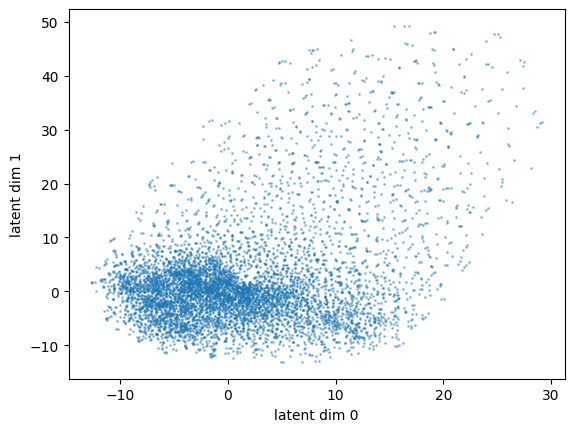

In [27]:
plt.scatter(latent_rep[:, 0], latent_rep[:, 1], s=1, alpha=0.4)
plt.xlabel('latent dim 0')
plt.ylabel('latent dim 1')
plt.show()